In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
import pickle

In [3]:
#Load Flirt Dataset
data = {
"message":[
"you look beautiful today",
"i miss you",
"thinking about you",
"good morning",
"did you finish the report",
"meeting at 5 pm",
"your smile is cute",
"i like talking with you",
"send the file",
"see you tomorrow"
],

"label":[
"flirt","flirt","flirt","not_flirt","not_flirt",
"not_flirt","flirt","flirt","not_flirt","not_flirt"
]
}

df = pd.DataFrame(data)

df.head()

,message,label
0,you look beautiful today,flirt
1,i miss you,flirt
2,thinking about you,flirt
3,good morning,not_flirt
4,did you finish the report,not_flirt


In [4]:
#Data Preprocessing
df["message"] = df["message"].str.lower()
df["message"] = df["message"].str.replace('[^a-z ]','',regex=True)

df.head()

,message,label
0,you look beautiful today,flirt
1,i miss you,flirt
2,thinking about you,flirt
3,good morning,not_flirt
4,did you finish the report,not_flirt


In [5]:
#Count Vectorizer + Logistic Regression
cv = CountVectorizer()

X = cv.fit_transform(df["message"])
y = df["label"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_lr))
print(classification_report(y_test,pred_lr))

Accuracy: 0.5
              precision    recall  f1-score   support

       flirt       0.50      1.00      0.67         1
   not_flirt       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\sjoyp\anaconda3\envs\tf310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sjoyp\anaconda3\envs\tf310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sjoyp\anaconda3\envs\tf310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [6]:
#Count Vectorizer + Naive Bayes
nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_nb))
print(classification_report(y_test,pred_nb))

Accuracy: 0.5
              precision    recall  f1-score   support

       flirt       0.50      1.00      0.67         1
   not_flirt       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\sjoyp\anaconda3\envs\tf310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sjoyp\anaconda3\envs\tf310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sjoyp\anaconda3\envs\tf310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [7]:
#TF-IDF Vectorizer + Logistic Regression
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(df["message"])

X_train,X_test,y_train,y_test = train_test_split(X_tfidf,y,test_size=0.2)

lr2 = LogisticRegression()

lr2.fit(X_train,y_train)

pred_tfidf_lr = lr2.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_tfidf_lr))

Accuracy: 0.0


In [8]:
#TF-IDF + Naive Bayes
nb2 = MultinomialNB()

nb2.fit(X_train,y_train)

pred_tfidf_nb = nb2.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_tfidf_nb))

Accuracy: 0.0


In [9]:
#Final Model
#Assume best accuracy comes from:
#TF-IDF + Multinomial Naive Bayes
final_vectorizer = TfidfVectorizer()

X_final = final_vectorizer.fit_transform(df["message"])

final_model = MultinomialNB()

final_model.fit(X_final,y)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [10]:
#Load WhatsApp Chat
chat = pd.read_csv("flirt_chat.txt",delimiter=" - ",header=None)

chat.columns=["datetime","message"]

chat.head()

C:\Users\sjoyp\AppData\Local\Temp\ipykernel_15888\1339787439.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  chat = pd.read_csv("flirt_chat.txt",delimiter=" - ",header=None)


,datetime,message
0,"12/02/2026, 08:15 AM",Rahul: Good morning 🙂
1,"12/02/2026, 08:16 AM",Priya: Good morning!
2,"12/02/2026, 08:17 AM",Rahul: Did you sleep well?
3,"12/02/2026, 08:18 AM","Priya: Yes, what about you?"
4,"12/02/2026, 08:19 AM","Rahul: Not really, I kept thinking about you 😉"


In [11]:
#Split User and Message
# Make sure 'message' column is string type
chat['message'] = chat['message'].astype(str)

# Split at first colon (:) safely
chat[['user','text']] = chat['message'].str.split(':', n=1, expand=True)

# Remove rows where user or text is NaN (optional)
chat = chat.dropna(subset=['user','text'])

chat.head()

,datetime,message,user,text
0,"12/02/2026, 08:15 AM",Rahul: Good morning 🙂,Rahul,Good morning 🙂
1,"12/02/2026, 08:16 AM",Priya: Good morning!,Priya,Good morning!
2,"12/02/2026, 08:17 AM",Rahul: Did you sleep well?,Rahul,Did you sleep well?
3,"12/02/2026, 08:18 AM","Priya: Yes, what about you?",Priya,"Yes, what about you?"
4,"12/02/2026, 08:19 AM","Rahul: Not really, I kept thinking about you 😉",Rahul,"Not really, I kept thinking about you 😉"


In [12]:
#Apply Flirt Prediction on WhatsApp Chat
chat["text"] = chat["text"].str.lower()

X_chat = final_vectorizer.transform(chat["text"].fillna(""))

chat["flirt_prediction"] = final_model.predict(X_chat)

chat.head()

,datetime,message,user,text,flirt_prediction
0,"12/02/2026, 08:15 AM",Rahul: Good morning 🙂,Rahul,good morning 🙂,not_flirt
1,"12/02/2026, 08:16 AM",Priya: Good morning!,Priya,good morning!,not_flirt
2,"12/02/2026, 08:17 AM",Rahul: Did you sleep well?,Rahul,did you sleep well?,not_flirt
3,"12/02/2026, 08:18 AM","Priya: Yes, what about you?",Priya,"yes, what about you?",flirt
4,"12/02/2026, 08:19 AM","Rahul: Not really, I kept thinking about you 😉",Rahul,"not really, i kept thinking about you 😉",flirt


In [13]:
#Talkative / Less Talkative Person
talkative = chat.groupby("user")["text"].count()

print(talkative)

user
Priya    15
Rahul    15
Name: text, dtype: int64


In [14]:
#Most Talkative
talkative.idxmax()

'Priya'

In [15]:
#Less Talkative
talkative.idxmin()

'Priya'

In [16]:
#Most Active Day
chat["datetime"] = pd.to_datetime(chat["datetime"])

chat["day"] = chat["datetime"].dt.day_name()

chat.groupby("day")["text"].count()

day
Wednesday    30
Name: text, dtype: int64

In [17]:
#Most Active Time
chat["hour"] = chat["datetime"].dt.hour

chat.groupby("hour")["text"].count()

hour
8     9
9     3
11    3
13    5
17    4
19    2
22    4
Name: text, dtype: int64

In [18]:
#Media Count Sent by Each Person
media = chat[chat["text"].str.contains("media",case=False,na=False)]

media.groupby("user").count()

,datetime,message,text,flirt_prediction,day,hour
user,,,,,,


In [19]:
#Missed calls
missed_calls = chat[chat["text"].str.contains("missed call",case=False,na=False)]

missed_calls.groupby("user").count()

,datetime,message,text,flirt_prediction,day,hour
user,,,,,,


In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

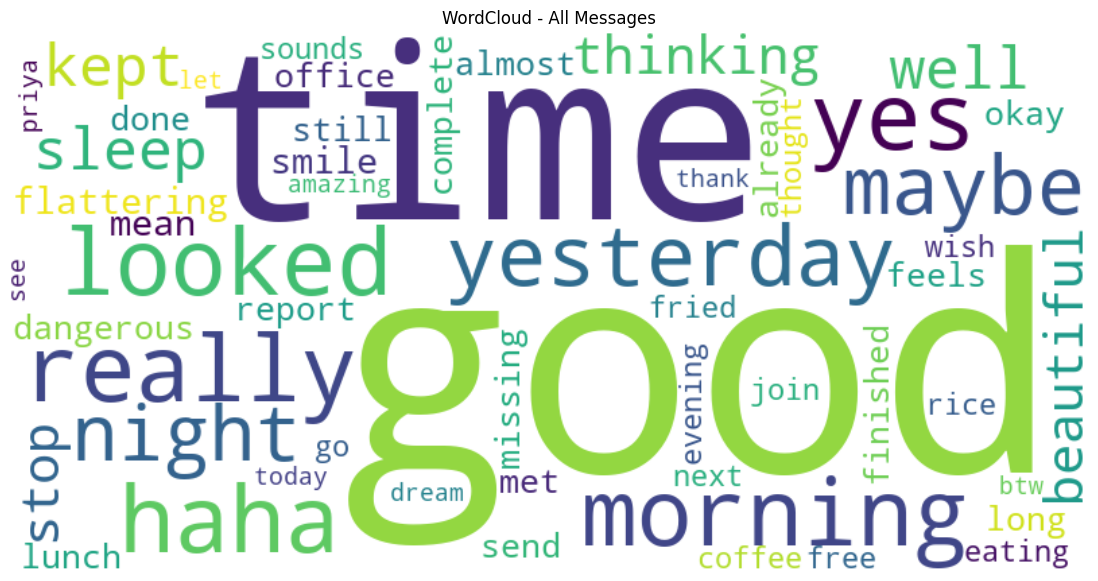

In [21]:
#WordCloud for All Messages
# Combine all text into a single string
all_text = " ".join(chat['text'].dropna())

# Generate WordCloud
wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Plot
plt.figure(figsize=(15,7))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - All Messages")
plt.show()

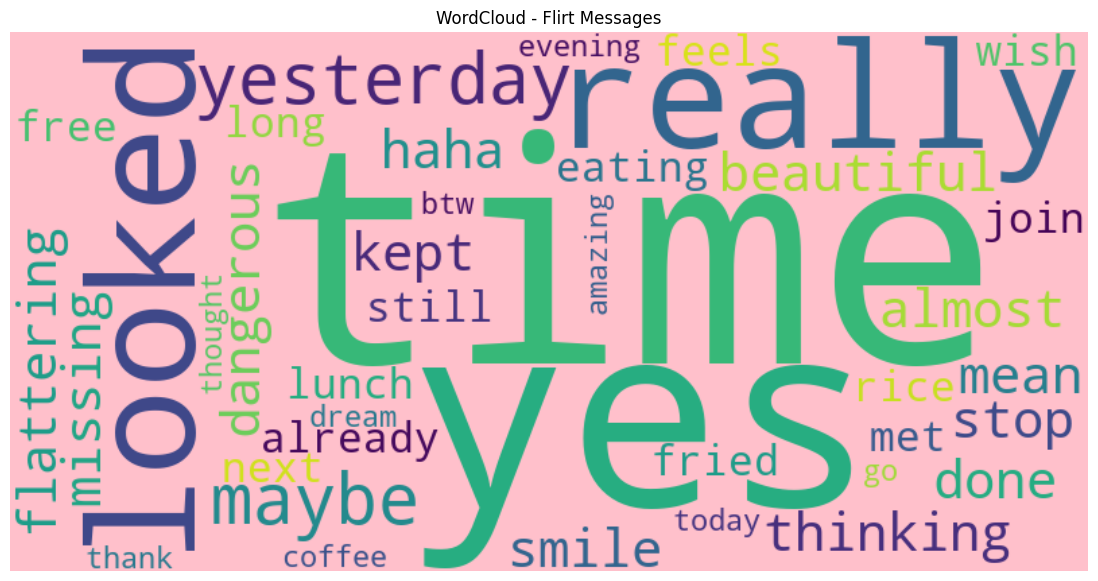

In [22]:
#WordCloud for Flirt Messages Only
flirt_text = " ".join(chat[chat['flirt_prediction']=='flirt']['text'].dropna())

wordcloud_flirt = WordCloud(width=800, height=400, background_color='pink').generate(flirt_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud_flirt, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Flirt Messages")
plt.show()

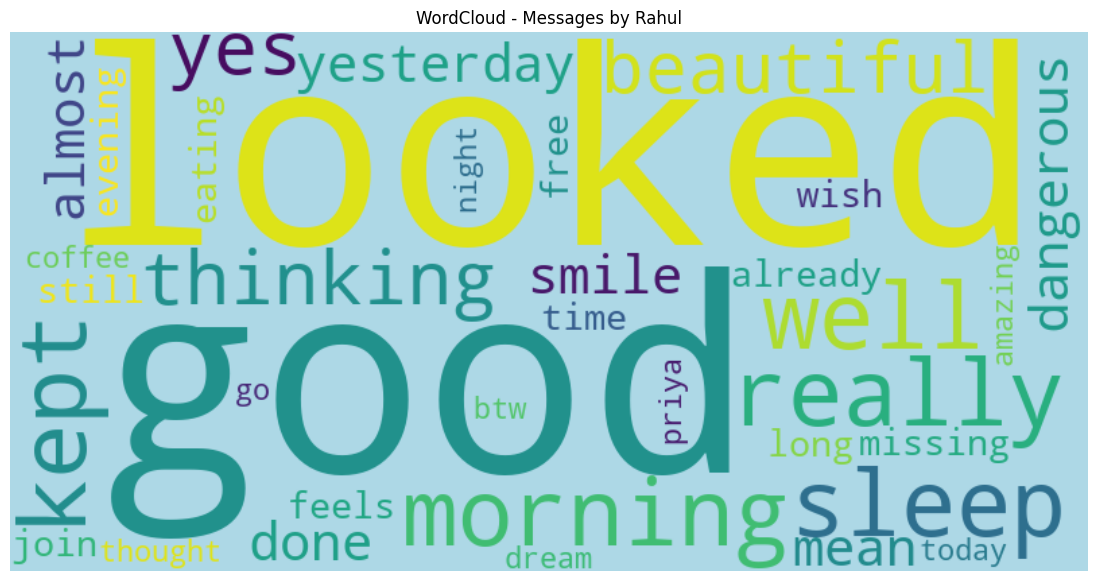

In [23]:
#WordCloud for a Specific Person
person_text = " ".join(chat[chat['user']=='Rahul']['text'].dropna())

wordcloud_person = WordCloud(width=800, height=400, background_color='lightblue').generate(person_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud_person, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Messages by Rahul")
plt.show()

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
# Make sure 'datetime' column is datetime type
chat["datetime"] = pd.to_datetime(chat["datetime"])

# Extract day of the week
chat["day"] = chat["datetime"].dt.day_name()

# Group by day
active_day = chat.groupby("day")["text"].count().sort_values(ascending=False)
active_day

day
Wednesday    30
Name: text, dtype: int64

C:\Users\sjoyp\AppData\Local\Temp\ipykernel_15888\3833156801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=active_day.index, y=active_day.values, palette="viridis")


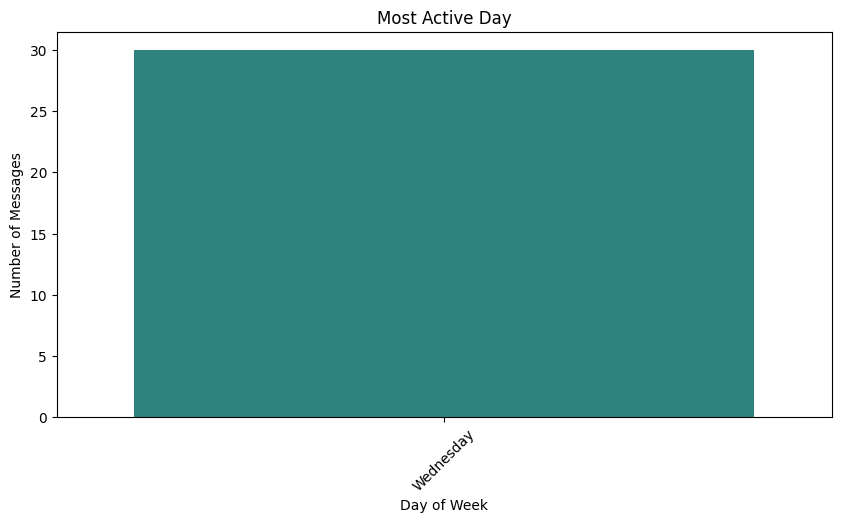

In [26]:
plt.figure(figsize=(10,5))
sns.barplot(x=active_day.index, y=active_day.values, palette="viridis")
plt.title("Most Active Day")
plt.xlabel("Day of Week")
plt.ylabel("Number of Messages")
plt.xticks(rotation=45)
plt.show()

In [27]:
plt.figure(figsize=(12,5))
sns.barplot(x=active_hour.index, y=active_hour.values, palette="magma")
plt.title("Most Active Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Messages")
plt.show()

NameError: name 'active_hour' is not defined

<Figure size 1200x500 with 0 Axes>

C:\Users\sjoyp\AppData\Local\Temp\ipykernel_15888\1092304737.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=talkative.index, y=talkative.values, palette="coolwarm")


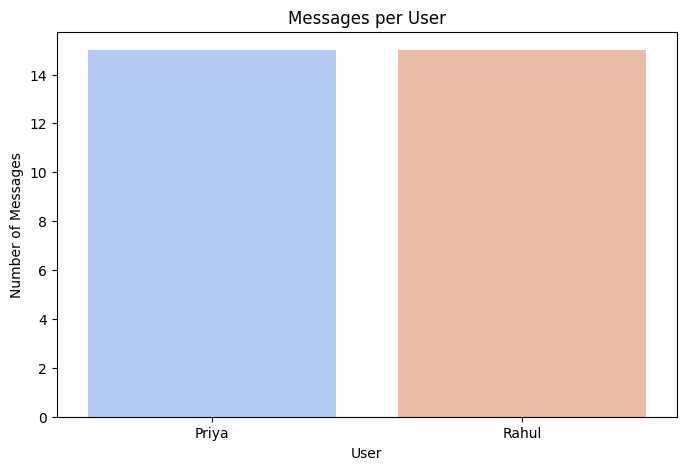

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x=talkative.index, y=talkative.values, palette="coolwarm")
plt.title("Messages per User")
plt.xlabel("User")
plt.ylabel("Number of Messages")
plt.show()

In [29]:
# Ensure 'text' column exists
chat['text'] = chat['text'].astype(str)

# Filter messages containing media
media = chat[chat['text'].str.contains("<media omitted>", case=False, na=False)]

# Count per user
media_count = media.groupby('user')['text'].count()

# If no media messages, media_count will be empty
print("Media Count per User:")
print(media_count)

Media Count per User:
Series([], Name: text, dtype: int64)


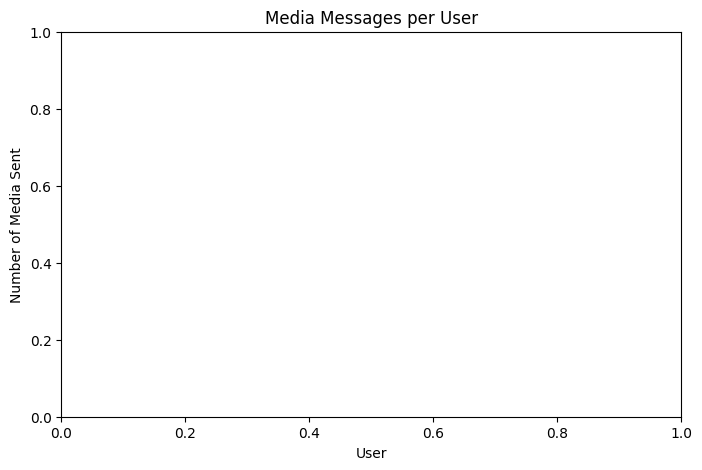

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(x=media_count.index, y=media_count.values, palette="Blues")
plt.title("Media Messages per User")
plt.xlabel("User")
plt.ylabel("Number of Media Sent")
plt.show()

In [31]:
import pickle

# Save model
with open('flirt_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)